# **Capstone Project: Healthcare Accessibility & Demand Modeling**
## **Identifying "Healthcare Deserts" in Houston, TX**

### **1.1 Executive Summary**
This project simulates a real-world use case for a **Healthcare Real Estate Investment Trust (REIT)** aiming to optimize facility placement. By modeling the relationship between demographic demand and healthcare facility density, we identify underserved ZIP codes—"healthcare deserts"—where high demand meets low supply.

### **1.2 Key Objectives**
* **Quantify healthcare facility density** per ZIP code using authoritative data.
* **Implement a custom Logistic Regression model** from scratch to demonstrate mathematical rigor.
* **Compare custom model performance** against scikit-learn's Logistic Regression as a benchmark.
* **Identify high-priority investment areas** based on demographic indicators like median age and income.

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Add the parent directory to the path so we can import our 'src' scripts
sys.path.append(os.path.abspath(".."))

from src.preprocessing import filter_by_city
from src.model import run_model, run_sklearn_model
from src.analysis import plot_cost_history, get_feature_importance, plot_confusion_matrix_visual, create_healthcare_desert_map

print("Environment Ready: Pipeline components imported.")

Environment Ready: Pipeline components imported.


---
## 2. Load & Prepare Houston Dataset

In [2]:
# Load the data generated by your EDA process
df = pd.read_csv("../data/processed_data.csv",dtype={'zip_code': str})

# Focus on Houston (simulating the multi-city capability you built)
houston_df = filter_by_city(df, "Houston")

print(f"Dataset loaded. Total Houston ZIP codes for analysis: {len(houston_df)}")
houston_df.head()

Dataset loaded. Total Houston ZIP codes for analysis: 220


,zip_code,median_age,total_population,median_household_income,bachelors_degree,masters_degree,below_poverty,unemployed,uninsured_adults,with_disability,no_vehicle_households,facility_count,facility_density,is_desert
515,77002,35.3,18800.0,78292.0,3103.0,1261.0,1603.0,259.0,25.0,8889.0,1106.0,9.0,0.478723,0
516,77003,33.9,10169.0,87618.0,2202.0,1151.0,2164.0,471.0,38.0,10150.0,645.0,4.0,0.393352,0
517,77004,33.3,35506.0,68141.0,7132.0,3534.0,8614.0,1697.0,805.0,35471.0,2083.0,32.0,0.901256,0
518,77005,36.8,28470.0,213059.0,6013.0,4024.0,1077.0,572.0,178.0,28430.0,496.0,1.0,0.035125,0
519,77006,33.5,24006.0,104375.0,7304.0,4321.0,2072.0,755.0,32.0,23961.0,980.0,9.0,0.374906,0


---
## 3. Modeling: Custom Implementation
To demonstrate deep technical understanding, this section utilizes a Logistic Regression model built using only **NumPy** for matrix operations. 

### 3.1 Mathematical Foundation
The model relies on three core components:
* **Sigmoid Function:** Maps linear outputs to a probability between 0 and 1.
* **Binary Cross-Entropy (Log Loss):** Penalizes incorrect classifications more heavily as confidence in the wrong prediction increases.
* **Gradient Descent:** An optimization algorithm that iteratively updates weights to minimize the cost function.

In [3]:
target_column = 'is_desert'

print("TRAINING CUSTOM LOGISTIC REGRESSION (FROM SCRATCH)...")
weights, cost_history, y_test, y_pred = run_model(houston_df, target_column)

TRAINING CUSTOM LOGISTIC REGRESSION (FROM SCRATCH)...
--- Training Custom Model ---
Iteration 0: Cost 0.6908901683864567
Iteration 100: Cost 0.5489755180988105
Iteration 200: Cost 0.4731132973844628
Iteration 300: Cost 0.423912678825849
Iteration 400: Cost 0.39002976277607926
Iteration 500: Cost 0.36568085963289665
Iteration 600: Cost 0.34752603627904277
Iteration 700: Cost 0.33354610616357233
Iteration 800: Cost 0.32247715685800843
Iteration 900: Cost 0.3135018132362024
Classification Report Custom Model:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93        37
           1       1.00      0.14      0.25         7

    accuracy                           0.86        44
   macro avg       0.93      0.57      0.59        44
weighted avg       0.88      0.86      0.82        44

Confusion Matrix:
[[37  0]
 [ 6  1]]


### **3.2 Model Training & Optimization**
The `run_model` function manages the full pipeline:
* **Feature Scaling:** Ensures all demographic features are on a comparable scale.
* **Bias Integration:** Adds an intercept term so the decision boundary is not forced through the origin.
* **Convergence Monitoring:** Tracks `cost_history` to verify that the gradient descent is successfully minimizing error.

### **3.3 Cost History Visualization**
**Interpretation:** A steadily decreasing curve in the cost history plot confirms that the optimization algorithm successfully converged to a local minimum.

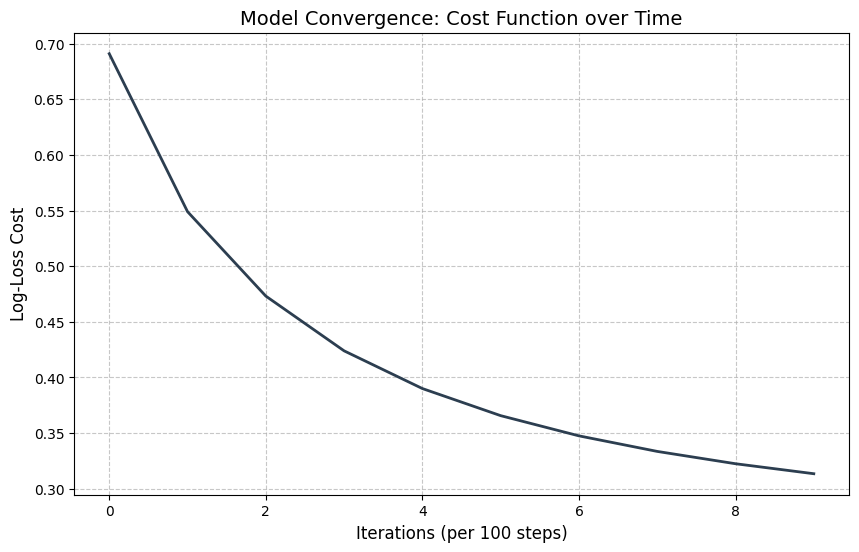

In [4]:
plot_cost_history(cost_history)

### 3.4 Feature Importance
The magnitude and sign of each weight shows which demographic factors drive the desert classification.

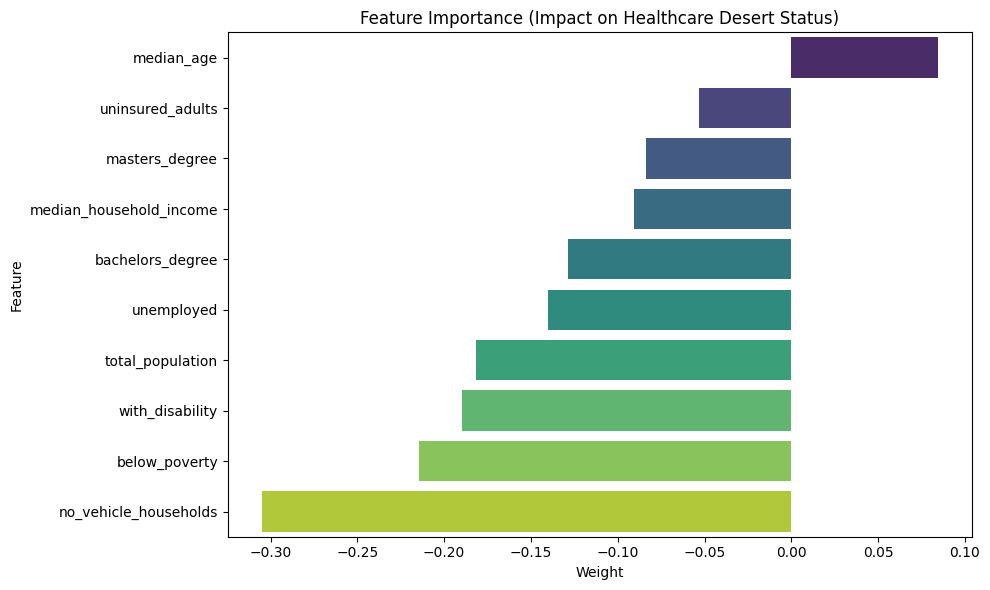

In [5]:
# Extract feature names (everything except the forbidden leakage columns)
feature_names = [col for col in houston_df.columns if col not in [target_column, 'facility_count', 'facility_density', 'zip_code']]

# Use the weights from Cell 4
importance = get_feature_importance(weights, feature_names)


Interpretation: Positive weights increase the probability of an area being a Healthcare Desert.

---
## 4. Scikit-learn Benchmark Model

Running sklearn's `LogisticRegression` on the same train/test split as a performance benchmark.

In [6]:
print("BENCHMARKING AGAINST SCIKIT-LEARN...")
# This confirms your custom math is reaching the same conclusion as industry-standard tools
y_test_sklearn, y_pred_sklearn = run_sklearn_model(houston_df, target_column)

BENCHMARKING AGAINST SCIKIT-LEARN...
Classification Report Scikit-learn Model:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        37
           1       0.67      0.29      0.40         7

    accuracy                           0.86        44
   macro avg       0.77      0.63      0.66        44
weighted avg       0.84      0.86      0.84        44

Confusion Matrix:
[[36  1]
 [ 5  2]]


### 4.1 Confusion Matrix

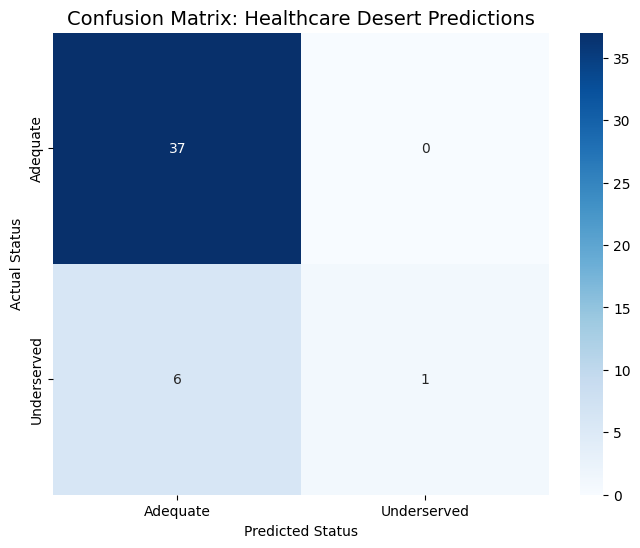

In [7]:
# Visualizing the final results for the REIT stakeholders
plot_confusion_matrix_visual(y_test, y_pred)

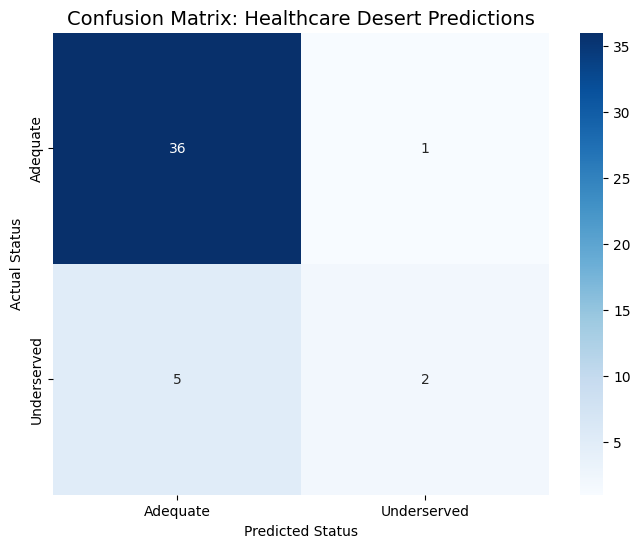

In [8]:
# Compare with sklearn's confusion matrix visualization
plot_confusion_matrix_visual(y_test_sklearn, y_pred_sklearn)

---
## 5. Model Comparison: Custom vs. Scikit-learn

Side-by-side accuracy, recall score and F1-score to see how close the custom implementation gets to the sklearn benchmark.

                Accuracy  F1-Score (Underserved)  Recall (Underserved)
Model                                                                 
Custom (NumPy)    0.8636                    0.25                0.1429
Scikit-learn      0.8636                    0.40                0.2857


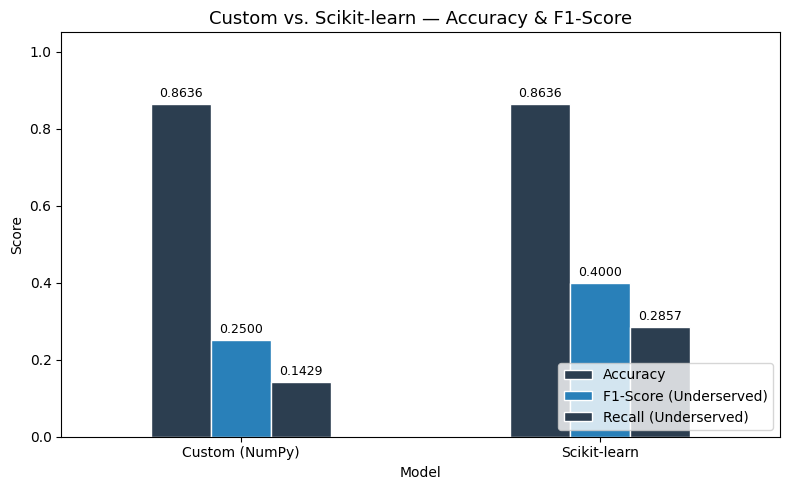

In [9]:
from sklearn.metrics import accuracy_score, f1_score, recall_score
import matplotlib.pyplot as plt
metrics = {
    'Model': ['Custom (NumPy)', 'Scikit-learn'],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test_sklearn, y_pred_sklearn)
    ],
    'F1-Score (Underserved)': [
        f1_score(y_test, y_pred),
        f1_score(y_test_sklearn, y_pred_sklearn)
    ],
    'Recall (Underserved)': [
        recall_score(y_test, y_pred),
        recall_score(y_test_sklearn, y_pred_sklearn)
    ]
}

comparison_df = pd.DataFrame(metrics).set_index('Model')
comparison_df = comparison_df.round(4)
print(comparison_df)

# Bar chart comparison
ax = comparison_df.plot(kind='bar', figsize=(8, 5), ylim=(0, 1.05), rot=0, 
                        color=['#2c3e50', '#2980b9'], edgecolor='white')
ax.set_title("Custom vs. Scikit-learn — Accuracy & F1-Score", fontsize=13)
ax.set_ylabel("Score")
ax.legend(loc='lower right')
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Top Priority ZIP Codes for Investment

ZIP codes flagged as healthcare deserts, ranked by median age (highest unmet need).

In [10]:
# Identify the specific ZIP codes flagged as high priority for the REIT
high_priority = houston_df[houston_df[target_column] == 1].sort_values(by='median_age', ascending=False)

print("TOP 5 PRIORITY ZIP CODES FOR NEW FACILITY INVESTMENT:")
print(high_priority[['zip_code', 'median_age', 'median_household_income']].head(5))

TOP 5 PRIORITY ZIP CODES FOR NEW FACILITY INVESTMENT:
    zip_code  median_age  median_household_income
619    77331        51.2                  50123.0
720    77565        48.4                  81921.0
659    77422        44.7                  68937.0
569    77059        44.5                 158958.0
632    77358        44.2                  71966.0


---
### 7. Geospatial Analysis: Mapping Healthcare Deserts

The final stage of this pipeline translates the Logistic Regression classifications into an interactive geospatial visualization. By overlaying our model’s "Healthcare Desert" flags onto official City of Houston ZIP code boundaries, we can identify high-priority clusters for infrastructure investment.

#### 7.1 Spatial Join & Visualization Logic
This visualization utilizes **Folium** for interactive rendering and **GeoPandas** to handle the underlying vector data.
* **Choropleth Layer:** Areas are shaded based on their "Desert" status (1 = Underserved, 0 = Served).
* **Strategic Overlay:** The map provides an immediate visual confirmation of the demand-supply gap identified by the model, allowing stakeholders to see the geographic relationship between neighboring ZIP codes.

In [11]:
# Path to your Houston ZIP code GeoJSON
geojson_file = '../data/zipcode.zip'


# Create the base choropleth map
houston_map = create_healthcare_desert_map(houston_df, geojson_file)

# Display the map directly in the notebook
houston_map

## **Strategic Recommendations**
Based on the model's classification of "healthcare deserts," the following ZIP codes are identified as high-priority for new facility investment due to high median ages and low existing facility density:

1.  **ZIP 77331:** Highest priority (Median Age: 51.2).
2.  **ZIP 77565:** (Median Age: 48.4).

### **4.1 Conclusion**
These findings provide the REIT with a data-driven roadmap for expansion, ensuring that new infrastructure is placed where it will have the highest community impact and demand.